In [1]:
### Analysis of artificially generated data for the purpose of conducting the Mann-Whitney test.

## Two sets of INDEPENDENT data were generated for women and men regarding stress levels in the same work environment. 
## When subjected to the Shapiro-Wilk test, they were found to be NON-Gaussian distribution.
## Therefore, since the groups are independent and the test used must be nonparametric, the U statistic of the Mann-Whitney test is applied. 

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, shapiro

In [4]:
# ============================================
# 1. Data Generation (Non-normal distribution)

# Data for 20 men
men_data = np.array(
    [
        12, 15, 18, 19, 20, 21, 22, 24, 25, 26,
        28, 30, 31, 33, 35, 38, 42, 47, 55, 70,
    ]
)

# Data for 20 women
women_data = np.array(
    [
        8, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        18, 19, 20, 21, 22, 24, 27, 31, 40, 58,
    ]
)

# Creating the DataFrame
df = pd.DataFrame({"Men": men_data, "Women": women_data})

print("Dataset Summary:")
print(df)

Dataset Summary:
    Men  Women
0    12      8
1    15     10
2    18     11
3    19     12
4    20     13
5    21     14
6    22     15
7    24     16
8    25     17
9    26     18
10   28     18
11   30     19
12   31     20
13   33     21
14   35     22
15   38     24
16   42     27
17   47     31
18   55     40
19   70     58


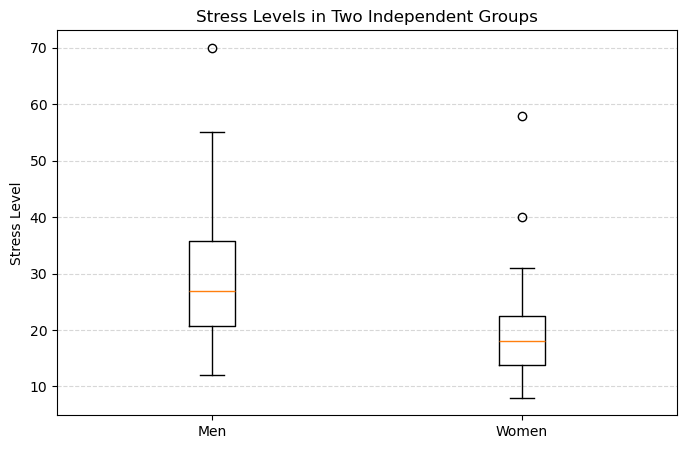

In [7]:
# =====================
# 2. Data Visualization

plt.figure(figsize=(8, 5))
plt.boxplot([men_data, women_data], labels=["Men", "Women"])
plt.title("Stress Levels in Two Independent Groups")
plt.ylabel("Stress Level")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [9]:
# ==============================
# 3. Shapiro-Wilk Normality Test

ALPHA = 0.05
shapiro_men = shapiro(men_data)
shapiro_women = shapiro(women_data)

print("\n===== SHAPIRO-WILK NORMAL DISTRIBUTION TEST =====")
print(
    f"Men: W = {shapiro_men.statistic:.4f}, " f"p-value = {shapiro_men.pvalue:.4f}")
if shapiro_men.pvalue < ALPHA:
    print("Reject H0 -> The distribution is NOT normal.")
else:
    print("Fail to reject H0 -> The distribution is normal.")

print()

print(
    f"Women: W = {shapiro_women.statistic:.4f}, "
    f"p-value = {shapiro_women.pvalue:.4f}")

if shapiro_women.pvalue < ALPHA:
    print("Reject H0 -> The distribution is NOT normal.")
else:
    print("Fail to reject H0 -> The distribution is normal.")


===== SHAPIRO-WILK NORMAL DISTRIBUTION TEST =====
Men: W = 0.9035, p-value = 0.0479
Reject H0 -> The distribution is NOT normal.

Women: W = 0.8079, p-value = 0.0011
Reject H0 -> The distribution is NOT normal.


In [11]:
# ======================
# 4. Mann-Whitney U Test

print("\n===== MANN-WHITNEY U TEST =====")
# H0: The distributions of both groups are equal
# H1: The distributions of both groups are different

u_stat, p_value = mannwhitneyu(men_data, women_data, alternative="two-sided")

print(f"U statistic = {u_stat:.2f}")
print(f"p-value = {p_value:.4f}")

if p_value < ALPHA:
    print("Reject H0.")
    print(
        "There is a statistically significant difference "
        "in stress levels between the groups.")
else:
    print("Fail to reject H0.")
    print("No statistically significant difference found between the groups.")


===== MANN-WHITNEY U TEST =====
U statistic = 302.00
p-value = 0.0060
Reject H0.
There is a statistically significant difference in stress levels between the groups.


In [13]:
## The Hodges-Lehmann estimator is a nonparametric measure of effect size. 
## In the context of the Mann-Whitney U test, it calculates the median of all possible differences 
## between pairs of observations from the two groups under study. 
## It allows us to determine exactly how much the distributions differ from one another.

In [15]:
# ======================================================
# 5. Hodges-Lehmann Estimator and 95% Confidence Interval

# Hodges-Lehmann estimator
differences = np.array([m - w for m in men_data for w in women_data])
hl_estimator = np.median(differences)

# Bootstrap confidence interval
n_boot = 10000
bootstrap_hl = []

rng = np.random.default_rng(seed=123)

for _ in range(n_boot):

    men_boot = rng.choice(men_data, size=len(men_data), replace=True)
    women_boot = rng.choice(women_data, size=len(women_data), replace=True)

    diff_boot = np.array([
        m - w
        for m in men_boot
        for w in women_boot
    ])

    bootstrap_hl.append(np.median(diff_boot))

bootstrap_hl = np.array(bootstrap_hl)

# 95% confidence interval based on bootstrap percentiles
ci_lower = np.percentile(bootstrap_hl, 2.5)
ci_upper = np.percentile(bootstrap_hl, 97.5)

print("\n===== HODGES-LEHMANN ESTIMATOR =====")
print(f"HL = {hl_estimator:.2f}")

print("\n===== 95% CONFIDENCE INTERVAL =====")
print(
    f"95% CI for the Hodges-Lehmann location difference: "
    f"[{ci_lower:.2f}, {ci_upper:.2f}]"
)

if ci_lower > 0 or ci_upper < 0:
    print(
        "The confidence interval does not include zero. "
        "The difference between groups is statistically significant."
    )
else:
    print(
        "The confidence interval includes zero. "
        "There is insufficient evidence to conclude a statistically. "
        "significant difference between the groups."
    )


===== HODGES-LEHMANN ESTIMATOR =====
HL = 9.00

===== 95% CONFIDENCE INTERVAL =====
95% CI for the Hodges-Lehmann location difference: [3.00, 15.00]
The confidence interval does not include zero. The difference between groups is statistically significant.


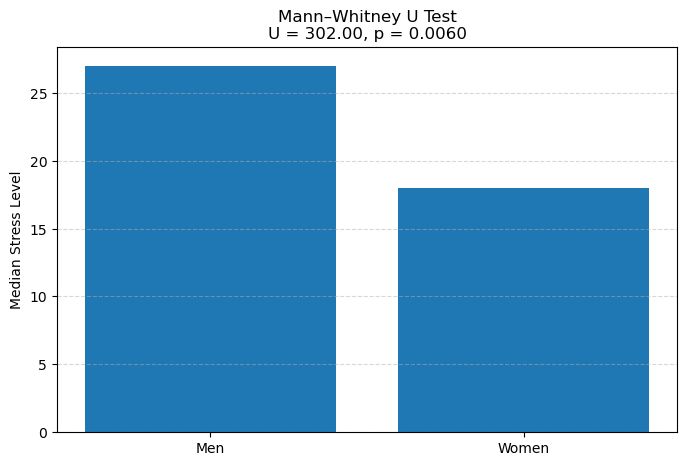

In [16]:
# =============================
# 6. Test Results Visualization

median_men = np.median(men_data)
median_women = np.median(women_data)

plt.figure(figsize=(8, 5))
plt.bar(["Men", "Women"], [median_men, median_women])

plt.title(f"Mann–Whitney U Test\n" f"U = {u_stat:.2f}, p = {p_value:.4f}")
plt.ylabel("Median Stress Level")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [21]:
### The Shapiro–Wilk test revealed significant deviations from normality in both 
### the men’s group (W = 0.903, p = 0.048) and the women’s group (W = 0.808, p = 0.001). 
### Since the assumption of normality was not met, the Mann–Whitney U test for independent samples was used. 
### The analysis revealed a significant difference in stress levels between the groups, U = 302, p = 0.006. 
### Stress levels were higher in the group of men than in the group of women.